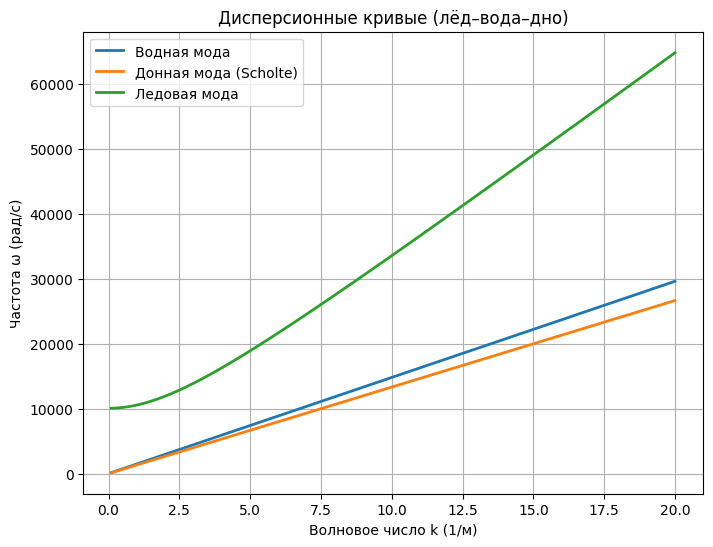

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Параметры среды
# -----------------------------
# Вода
c_w = 1480      # скорость звука в воде (м/с)

# Лёд (упругая среда)
c_l = 3200      # продольная скорость (м/с)
c_s = 1600      # поперечная скорость (м/с)
h_ice = 1.0     # толщина льда (м)

# Дно (грунт)
c_bottom = 1800  # эффективная скорость (м/с)

# Скорость донной (Scholte) волны (приближение)
c_scholte = 0.9 * c_w

# -----------------------------
# Волновое число
# -----------------------------
k = np.linspace(0.1, 20, 500)  # волновое число

# -----------------------------
# 1. Водная мода
# ω = c * k
# -----------------------------
omega_water = c_w * k

# -----------------------------
# 2. Донная мода (Scholte)
# -----------------------------
omega_bottom = c_scholte * k

# -----------------------------
# 3. Ледовая мода (упрощённая дисперсия Лэмба)
# tan(qh) ~ 0 → qh ≈ nπ
# q^2 = (ω/c_l)^2 - k^2
# -----------------------------

omega_ice = []

for ki in k:
    # решаем уравнение приближённо
    # ω^2 = c_l^2 (k^2 + (nπ/h)^2)
    n = 1  # первая мода
    omega = c_l * np.sqrt(ki**2 + (n * np.pi / h_ice)**2)
    omega_ice.append(omega)

omega_ice = np.array(omega_ice)

# -----------------------------
# Построение графика
# -----------------------------
plt.figure(figsize=(8, 6))

plt.plot(k, omega_water, label="Водная мода", linewidth=2)
plt.plot(k, omega_bottom, label="Донная мода (Scholte)", linewidth=2)
plt.plot(k, omega_ice, label="Ледовая мода", linewidth=2)

plt.xlabel("Волновое число k (1/м)")
plt.ylabel("Частота ω (рад/с)")
plt.title("Дисперсионные кривые (лёд–вода–дно)")

plt.legend()
plt.grid()

plt.show()